# A carbon cycle model with sliders

*Cambio* is a carbon mass-balance model small enough for undergraduates to build themselves: three reservoirs (atmosphere, land, oceans), a handful of fluxes between them, and a loop that steps the reservoirs forward in time. This notebook is the completed model with sliders attached, so you can change the emissions scenario and watch the atmosphere and oceans respond.

The fluxes, in GtC per year:

$$F_{la} = k_{la}, \qquad F_{al} = k_{al0} + k_{al1}\,C_{atm}, \qquad F_{oa} = k_{oa}\,C_{ocean}, \qquad F_{ao} = k_{ao}\,C_{atm}, \qquad F_{ha} = \epsilon(t)$$

where $F_{ha}$ is anthropogenic emission. At each time step the reservoirs are updated by Euler's method:

$$C_{atm} \leftarrow C_{atm} + (F_{la} + F_{oa} + F_{ha} - F_{al} - F_{ao})\,\Delta t, \qquad C_{ocean} \leftarrow C_{ocean} + (F_{ao} - F_{oa})\,\Delta t$$

*Adapted from:* Neshyba, S.; Posta, F.; Pfalzgraff, W. C.; Eklof, J.; Neshyba-Rowe, D. P.; Rowe, P. M. CAMBIO: A Carbon Mass Balance Model for Undergraduates. *Bull. Am. Meteorol. Soc.* **2026**, *107* (1), E26–E43. [https://doi.org/10.1175/BAMS-D-25-0069.1](https://doi.org/10.1175/BAMS-D-25-0069.1)

In [1]:
%pip install -q ipympl ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib widget

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

## The emissions scenario

Emissions grow exponentially at 1.66% per year, pegged to 9 GtC/yr in 2003, peak in a year you choose, decline over a decarbonization time, and level off at a long-term value.

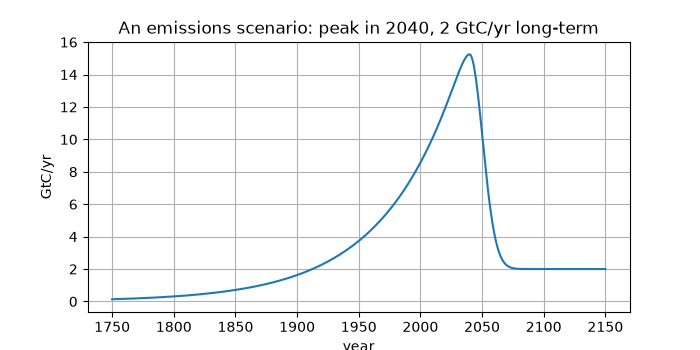

In [4]:
def emissions(time, t_peak, t_decarb, eps_longterm, k=0.0166, eps_0=9, t_0=2003):
    """Anthropogenic emissions (GtC/yr) on the array `time` (years)."""
    tp1 = t_peak + (t_decarb/3)*np.log(3/(k*t_decarb) - 1)
    eps = np.exp(k*time) * eps_0*np.exp(-k*t_0) * np.exp(3/t_decarb*(tp1 - time)) / (1 + np.exp(3/t_decarb*(tp1 - time)))
    # after the peak, relax toward the long-term value instead of toward zero
    ipeak = np.argmax(eps)
    tail = eps_longterm + (eps[ipeak] - eps_longterm)*np.exp(-((time - time[ipeak])/t_decarb)**2)
    return np.where(time <= time[ipeak], eps, tail)

time = np.linspace(1750, 2150, 600)
plt.figure(figsize=(7, 3.5))
plt.plot(time, emissions(time, 2040, 15, 2))
plt.xlabel('year'); plt.ylabel('GtC/yr'); plt.title('An emissions scenario: peak in 2040, 2 GtC/yr long-term'); plt.grid(True)

## The model

Preindustrial reservoirs: 590 GtC in the atmosphere, 411 GtC in the surface ocean. The rate constants are those of the reference.

In [5]:
def run_cambio(time, eps, C_atm=590, C_ocean=411,
               k_la=120, k_al0=110.7, k_al1=0.01579, k_oa=0.1694, k_ao=0.1179):
    """Euler integration of the two-reservoir model. Returns arrays over `time`."""
    dt = time[1] - time[0]
    n = len(time)
    C_atm_arr, C_ocean_arr = np.zeros(n), np.zeros(n)
    F_land_net, F_ocean_net = np.zeros(n), np.zeros(n)
    for i in range(n):
        F_la = k_la
        F_al = k_al0 + k_al1*C_atm
        F_oa = k_oa*C_ocean
        F_ao = k_ao*C_atm
        C_atm = C_atm + (F_la + F_oa + eps[i] - F_al - F_ao)*dt
        C_ocean = C_ocean + (F_ao - F_oa)*dt
        C_atm_arr[i], C_ocean_arr[i] = C_atm, C_ocean
        F_land_net[i], F_ocean_net[i] = F_la - F_al, F_oa - F_ao
    return C_atm_arr, C_ocean_arr, F_land_net, F_ocean_net

## Explore

Move the sliders. The left panel shows carbon in the atmosphere (also as CO$_2$ in ppm, on the right axis) and in the ocean. The right panel shows the anthropogenic emissions and the *net* fluxes from land and ocean to the atmosphere: negative means that reservoir is a sink.

Two things to look for: the year the ocean turns from a sink into a source, and the delay between peak emissions and peak atmospheric CO$_2$.

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5), layout='constrained')
ax1b = ax1.twinx()                                   # ppm axis, created once
ax1b.set_ylim(350/2.13, 1300/2.13); ax1b.set_ylabel('atmospheric CO$_2$ (ppm)')

def update(peak_year=IntSlider(min=2025, max=2080, step=5, value=2040),
           decarbonization_time=IntSlider(min=5, max=40, step=5, value=15),
           long_term_emissions=FloatSlider(min=0, max=8, step=0.5, value=2)):
    eps = emissions(time, peak_year, decarbonization_time, long_term_emissions)
    C_atm, C_ocean, F_land_net, F_ocean_net = run_cambio(time, eps)

    ax1.clear()
    ax1.plot(time, C_atm, 'r', label='atmosphere')
    ax1.plot(time, C_ocean, 'b', label='ocean')
    ax1.set_xlabel('year'); ax1.set_ylabel('carbon (GtC)'); ax1.set_ylim(350, 1300)
    ax1.legend(loc='upper left'); ax1.grid(True)

    ax2.clear()
    ax2.plot(time, eps, 'k', label='anthropogenic')
    ax2.plot(time, F_land_net, color='brown', label='land, net')
    ax2.plot(time, F_ocean_net, 'b', label='ocean, net')
    ax2.plot(time, eps + F_land_net + F_ocean_net, 'g--', label='combined')
    ax2.axhline(0, color='0.5', linewidth=0.8)
    ax2.set_xlabel('year'); ax2.set_ylabel('flux to atmosphere (GtC/yr)'); ax2.set_ylim(-12, 20)
    ax2.legend(loc='upper left'); ax2.grid(True)
    fig.canvas.draw_idle()

interact(update);

interactive(children=(IntSlider(value=2040, description='peak_year', max=2080, min=2025, step=5), IntSlider(va…

## Your turn

Set the long-term emissions to zero and find the earliest peak year for which atmospheric CO$_2$ stays below 500 ppm. Then set the peak to 2080 and watch what the ocean does late in the century.